<a href="https://colab.research.google.com/github/SNK005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SNK005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Can March 2026 page-level search and engagement signals identify which pages are most likely to experience a greater than 20% decline in GSC impressions in April 2026?

**Decision supported:** The result is intended to help prioritize pages for human review and possible content-refresh consideration. It is decision-support, not an automatic refresh decision.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:** FlyRank/internship-warehouse (v20260703), table `fact_content_daily_performance`.

**Tables:** `fact_content_daily_performance` only, for this stage — daily search performance, partitioned by `month=YYYY-MM`.

**Date windows:** March 2026 was used as the development month for the input features, and April 2026 was used as the forward label window. This follows the project's workflow of using a historical development period to predict the subsequent month's performance.


**Exclusions:** Rows where `gsc_data_available` is not TRUE are excluded (per data dictionary, this flag can be NULL, not just TRUE/FALSE — `IS TRUE` filtering avoids silently treating missing data as zero).Pages with no usable April GSC record (18,189 of 176,738 March pages) are excluded from labeled modeling because an April outcome cannot be reliably constructed for those pages.


**GA4 coverage limitation:** Of 176,738 March pages, 63.9% had zero GA4-tracked days in March, and only 0.1% had full-month coverage. This affects all 47 clients in this slice. GA4-derived features (`engaged_sessions_month`, `sessions_month`, `ai_sessions_month`) are therefore missing for the majority of pages and are median-imputed for modeling — meaning these features carry limited signal for most of the dataset. Impressions and clicks (GSC-based) remain the primary reliable signals in this analysis.

**Public-safe:** No client names, domains, or raw exports are stored — only pseudonymous hash IDs.

In [ ]:
!pip install -q duckdb huggingface_hub

import duckdb
from getpass import getpass

hf_token = getpass("Paste your Hugging Face token: ")

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")

# This is the missing piece — tells DuckDB's hf:// reader to actually use your token
con.sql(f"""
CREATE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
);
""")

BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

schema = con.sql(f"DESCRIBE SELECT * FROM read_parquet('{BASE}/month=2026-03/*.parquet') LIMIT 1")
schema.show(max_rows=60)

Paste your Hugging Face token: ··········
┌──────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│       column_name        │ column_type │  null   │   key   │ default │  extra  │
│         varchar          │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date              │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available       │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available       │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions          │ BIGINT      │ YE

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label definition:** `is_declining_next_month = 1` if a page's GSC impressions drop more than 20% from March to April 2026, else 0. This mirrors the −20% threshold the starter dataset's own `trend_direction` used, applied here as a genuine forward-looking (April) outcome instead of a same-window proxy — avoiding the leakage problem identified in ML-04.

**Entity-join audit:** The March-to-April outcome join uses `content_hash_id`. Before relying on this key, the notebook checks whether any March content ID is associated with more than one client. No cross-client content IDs were found in the March GSC slice, supporting the use of `content_hash_id` as the page-level join key for this analysis.


**Features:** March 2026 monthly aggregates — impressions, clicks, average position (impression-weighted), engaged sessions, sessions, AI-referred sessions. All computed from `fact_content_daily_performance` only, using pre-label-period (March) data.

**Baseline:** ML-07's frozen rule-based action score, kept unchanged for fair comparison.

**Validation design:** The feature window is temporally separated from the outcome window: March 2026 data is used to construct the input features, while April 2026 performance is used only to construct the forward-looking label. Within the resulting labeled dataset, `GroupShuffleSplit` is then used to hold out entire clients from training. The final split contains 36 training clients and 10 test clients, with zero client overlap. This design reduces the risk that the model is evaluated on pages from clients whose patterns it has already seen during training.


**Leakage checks:** `trend_direction`/`trend_pct` are not used (they don't exist in this table). April's own impressions are used only to construct the label, never as a feature.

In [ ]:
BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

query = f"""
WITH march AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_month,
        SUM(gsc_clicks) AS clicks_month,
        SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_position_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions END) AS engaged_sessions_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions END) AS sessions_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_ai END) AS ai_sessions_month,
        BOOL_OR(ga4_data_available IS TRUE) AS ga4_available_march,
        COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS ga4_days_available_march
    FROM read_parquet('{BASE}/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
),
april AS (
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS impressions_april
    FROM read_parquet('{BASE}/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
)
SELECT
    m.*,
    a.impressions_april,
    CASE
        WHEN a.impressions_april IS NULL THEN NULL
        WHEN m.impressions_month = 0 THEN NULL
        ELSE (a.impressions_april - m.impressions_month) * 1.0 / m.impressions_month
    END AS pct_change,
    CASE
        WHEN a.impressions_april IS NULL THEN NULL
        WHEN m.impressions_month = 0 THEN NULL
        WHEN (a.impressions_april - m.impressions_month) * 1.0 / m.impressions_month < -0.20 THEN 1
        ELSE 0
    END AS is_declining_next_month
FROM march m
LEFT JOIN april a ON m.content_hash_id = a.content_hash_id
"""

df = con.sql(query).df()
print("Total rows:", len(df))
print("Rows with a valid label (present in both months):", df['is_declining_next_month'].notna().sum())
print(df['is_declining_next_month'].value_counts(dropna=False))
df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total rows: 176738
Rows with a valid label (present in both months): 158549
is_declining_next_month
0       82738
1       75811
<NA>    18189
Name: count, dtype: Int64


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,ga4_available_march,ga4_days_available_march,impressions_april,pct_change,is_declining_next_month
0,content_b7e512995f79d5a6,client_73cda7b4e4f265ea,1140.0,2.0,4.450877,NaN,NaN,NaN,False,0,1151.0,0.009649,0
1,content_a7da352b73b02668,client_73cda7b4e4f265ea,4944.0,13.0,7.435680,0.0,2.0,0.0,True,2,6091.0,0.231998,0
2,content_d056587ff7faca0c,client_73cda7b4e4f265ea,2770.0,16.0,3.950542,0.0,3.0,0.0,True,2,6266.0,1.262094,0
3,content_bfd1e41c2af250c8,client_73cda7b4e4f265ea,48.0,0.0,18.145833,NaN,NaN,NaN,False,0,98.0,1.041667,0
4,content_2662845f598544ef,client_73cda7b4e4f265ea,150.0,1.0,7.506667,0.0,1.0,0.0,True,1,100.0,-0.333333,1
5,content_1855a661b4d36130,client_73cda7b4e4f265ea,429.0,1.0,3.871795,0.0,2.0,0.0,True,2,287.0,-0.331002,1
6,content_22c063002b7c1caf,client_73cda7b4e4f265ea,314.0,1.0,10.057325,NaN,NaN,NaN,False,0,322.0,0.025478,0
7,content_d720dde3701523c0,client_73cda7b4e4f265ea,132.0,1.0,30.863636,NaN,NaN,NaN,False,0,70.0,-0.469697,1
8,content_419dc7d89aee9698,client_73cda7b4e4f265ea,1868.0,6.0,5.581370,0.0,18.0,0.0,True,4,1946.0,0.041756,0
9,content_a36aa972b8edda8f,client_73cda7b4e4f265ea,151.0,1.0,25.503311,0.0,2.0,0.0,True,2,176.0,0.165563,0


In [ ]:
total = len(df)
no_ga4 = (df['ga4_available_march'] == False).sum()
partial_ga4 = ((df['ga4_available_march'] == True) & (df['ga4_days_available_march'] < 31)).sum()
full_ga4 = (df['ga4_days_available_march'] == 31).sum()

print(f"Total pages: {total}")
print(f"No GA4 all month: {no_ga4} ({no_ga4/total*100:.1f}%)")
print(f"Partial GA4 coverage: {partial_ga4} ({partial_ga4/total*100:.1f}%)")
print(f"Full GA4 coverage (31/31 days): {full_ga4} ({full_ga4/total*100:.1f}%)")

# How many distinct clients have zero GA4 at all?
clients_no_ga4 = df.loc[df['ga4_available_march'] == False, 'client_hash_id'].nunique()
total_clients = df['client_hash_id'].nunique()
print(f"\nClients with zero GA4 in March: {clients_no_ga4} of {total_clients}")

Total pages: 176738
No GA4 all month: 112882 (63.9%)
Partial GA4 coverage: 63724 (36.1%)
Full GA4 coverage (31/31 days): 132 (0.1%)

Clients with zero GA4 in March: 47 of 47


In [ ]:
# Check whether content_hash_id maps to more than one client
# before relying on the March-to-April join.

cross_client_check = con.sql(f"""
SELECT
    content_hash_id,
    COUNT(DISTINCT client_hash_id) AS client_count
FROM read_parquet('{BASE}/month=2026-03/*.parquet')
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
HAVING COUNT(DISTINCT client_hash_id) > 1
LIMIT 20
""").df()

print("Content IDs linked to multiple clients:", len(cross_client_check))
display(cross_client_check)

Content IDs linked to multiple clients: 0


,content_hash_id,client_count


In [ ]:
# Keep only rows where we have a real label
model_df = df[df['is_declining_next_month'].notna()].copy()
model_df['is_declining_next_month'] = model_df['is_declining_next_month'].astype(int)

print("Final modeling dataset:", model_df.shape)
print(model_df['is_declining_next_month'].value_counts(normalize=True))

# Save so we don't have to re-query the warehouse every time
model_df.to_csv('capstone_march_features_april_label.csv', index=False)

Final modeling dataset: (158549, 13)
is_declining_next_month
0    0.521845
1    0.478155
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

FEATURES = [
    'impressions_month',
    'clicks_month',
    'avg_position_month',
    'engaged_sessions_month',
    'sessions_month',
    'ai_sessions_month'
]

TARGET = 'is_declining_next_month'
GROUP = 'client_hash_id'

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()
groups = model_df[GROUP].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

assert len(train_clients & test_clients) == 0, \
    "Leakage detected: train and test clients overlap."

assert len(X_train) + len(X_test) == len(model_df), \
    "Split size mismatch."

print("Leakage checks passed.")

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Leakage checks passed.
Train rows: 137445
Test rows: 21104
Train clients: 36
Test clients: 10
Client overlap: 0
Train positive rate: 0.4751
Test positive rate: 0.4981


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier

#simple decision tree modal
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)


# Predict probabilities and classes on the untouched test set
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Basic test metrics
from sklearn.metrics import precision_score, recall_score, roc_auc_score # Ensure these are imported as well
precision = precision_score(y_test, test_pred, zero_division=0)
recall = recall_score(y_test, test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, test_prob)

print("Decision Tree — test set")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

Decision Tree — test set
Precision: 0.5433
Recall: 0.4479
ROC-AUC: 0.5941


In [ ]:
# Precision@K comparison
# K = 50, matching the ML-01 / ML-07 evaluation convention

K = 50

# Model: take the 50 pages with the highest predicted probability
top_k_idx = test_prob.argsort()[::-1][:K]
model_precision_at_50 = y_test.iloc[top_k_idx].mean()

print("Model Precision@50:", round(model_precision_at_50, 4))

Model Precision@50: 0.62


In [ ]:
# ML-07 frozen baseline on the same test split
# Rule: impressions >= 500, average position <= 10, CTR < 1%
# Among qualifying pages, higher impressions get higher priority.

baseline_test = X_test.copy()

baseline_test['ctr_month'] = (
    baseline_test['clicks_month'] /
    baseline_test['impressions_month'].replace(0, float('nan'))
)

baseline_test['baseline_score'] = 0

qualifies = (
    (baseline_test['impressions_month'] >= 500) &
    (baseline_test['avg_position_month'] <= 10) &
    (baseline_test['ctr_month'] < 0.01)
)

baseline_test.loc[qualifies, 'baseline_score'] = (
    baseline_test.loc[qualifies, 'impressions_month']
)

# Rank the test pages using the frozen baseline score
baseline_top_k_idx = (
    baseline_test['baseline_score']
    .sort_values(ascending=False)
    .head(K)
    .index
)

baseline_precision_at_50 = y_test.loc[baseline_top_k_idx].mean()

print("Baseline Precision@50:", round(baseline_precision_at_50, 4))
print("Baseline qualifying pages in test set:", int(qualifies.sum()))

Baseline Precision@50: 0.38
Baseline qualifying pages in test set: 5131


In [ ]:
# Honest model vs baseline comparison

comparison = {
    "ML-07 baseline Precision@50": baseline_precision_at_50,
    "Decision Tree Precision@50": model_precision_at_50,
    "Decision Tree Precision": precision,
    "Decision Tree Recall": recall,
    "Decision Tree ROC-AUC": roc_auc
}

for metric, value in comparison.items():
    print(f"{metric}: {value:.4f}")

print(
    "\nPrecision@50 improvement:",
    f"{(model_precision_at_50 - baseline_precision_at_50):.4f}"
)

ML-07 baseline Precision@50: 0.3800
Decision Tree Precision@50: 0.6200
Decision Tree Precision: 0.5433
Decision Tree Recall: 0.4479
Decision Tree ROC-AUC: 0.5941

Precision@50 improvement: 0.2400


### 4.1 Baseline comparison

The Decision Tree is evaluated against the frozen ML-07 rule-based baseline on the same client-held-out test set. Precision@50 is used as the primary ranking metric because the practical goal is to identify a limited set of pages for human review.

The numerical result reported here should be taken directly from the final executed model-comparison output below. The baseline remains unchanged from ML-07, so the comparison measures whether the learned model improves top-of-queue ranking quality relative to the previously defined rule.


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# Preprocessing for Logistic Regression:
# fill missing feature values using training-set medians,
# then standardize the features.

logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.5).astype(int)

# Ensure these are imported from sklearn.metrics as needed
from sklearn.metrics import precision_score, recall_score, roc_auc_score

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)

logistic_top_k_idx = logistic_prob.argsort()[::-1][:K]
logistic_precision_at_50 = y_test.iloc[logistic_top_k_idx].mean()

print("Logistic Regression — test set")
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))
print("Precision@50:", round(logistic_precision_at_50, 4))

Logistic Regression — test set
Precision: 0.7052
Recall: 0.1067
ROC-AUC: 0.611
Precision@50: 0.7


### 4.2 Logistic Regression

Logistic Regression provides a simple linear comparison against the tree-based models. Missing feature values are handled using medians fitted on the training data, and the features are standardized before fitting the model.

The reported test-set metrics are generated directly by the executed notebook and are included in the final model-comparison table below. Precision@50 is evaluated using the same held-out test set and the same top-50 ranking procedure used for the other models.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
random_forest = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

# Predictions on the same untouched client-held-out test set
rf_prob = random_forest.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

rf_top_k_idx = rf_prob.argsort()[::-1][:K]
rf_precision_at_50 = y_test.iloc[rf_top_k_idx].mean()

print("Random Forest — test set")
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))
print("Precision@50:", round(rf_precision_at_50, 4))

Random Forest — test set
Precision: 0.5987
Recall: 0.4768
ROC-AUC: 0.6291
Precision@50: 0.8


In [ ]:
import pandas as pd

# Final model comparison on the same client-held-out test set

model_comparison = pd.DataFrame({
    'Approach': [
        'ML-07 frozen baseline',
        'Decision Tree',
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision@50': [
        baseline_precision_at_50,
        model_precision_at_50,
        logistic_precision_at_50,
        rf_precision_at_50
    ],
    'Precision': [
        None,
        precision,
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        None,
        recall,
        logistic_recall,
        rf_recall
    ],
    'ROC-AUC': [
        None,
        roc_auc,
        logistic_roc_auc,
        rf_roc_auc
    ]
})

display(model_comparison)

print(
    "Random Forest improvement over ML-07:",
    round(rf_precision_at_50 - baseline_precision_at_50, 4)
)

,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.62,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.80,0.598662,0.476788,0.629113


Random Forest improvement over ML-07: 0.42


### 4.3 Model comparison and selection

The three learned models are compared with the frozen ML-07 baseline on the same client-held-out test set. Precision@50 is the primary ranking metric because the intended use is to prioritize a limited number of pages for human review. Precision, recall, and ROC-AUC are reported as supporting metrics.

The Random Forest is selected as the final model using the combination of the primary ranking result and overall discrimination measured by ROC-AUC. Where two models have the same or similar Precision@50, ROC-AUC provides an additional basis for selection. The final model should be interpreted as a ranking and decision-support tool rather than as a guarantee of individual future outcomes.


In [ ]:
# Random Forest feature importance

rf_model = random_forest.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,impressions_month,0.547168
1,clicks_month,0.188869
2,avg_position_month,0.160626
4,sessions_month,0.080352
3,engaged_sessions_month,0.013805
5,ai_sessions_month,0.009180


In [ ]:
# Error analysis: false positives and false negatives

error_analysis = X_test.copy()

error_analysis['content_hash_id'] = model_df.iloc[test_idx]['content_hash_id'].values
error_analysis['client_hash_id'] = model_df.iloc[test_idx]['client_hash_id'].values
error_analysis['actual_label'] = y_test.values
error_analysis['predicted_probability'] = rf_prob
error_analysis['predicted_label'] = rf_pred

false_positives = error_analysis[
    (error_analysis['actual_label'] == 0) &
    (error_analysis['predicted_label'] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis['actual_label'] == 1) &
    (error_analysis['predicted_label'] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nTop false positives:")
display(
    false_positives.sort_values(
        'predicted_probability',
        ascending=False
    ).head(10)
)

print("\nTop false negatives:")
display(
    false_negatives.sort_values(
        'predicted_probability',
        ascending=False
    ).head(10)
)

False positives: 3360
False negatives: 5500

Top false positives:


,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,content_hash_id,client_hash_id,actual_label,predicted_probability,predicted_label
63914,3900.0,0.0,29.091026,1.0,204.0,0.0,content_7bead710b3839213,client_fef1a8f436438636,0,0.712266,1
152620,904.0,1.0,11.039823,5.0,643.0,0.0,content_a01948b37fc0fc9c,client_fef1a8f436438636,0,0.690234,1
46438,498.0,0.0,8.795181,0.0,60.0,0.0,content_376b21273b88185a,client_fef1a8f436438636,0,0.662873,1
97980,337.0,0.0,10.646884,0.0,81.0,0.0,content_26d21185158da25a,client_fef1a8f436438636,0,0.659336,1
45440,285.0,0.0,4.007018,0.0,83.0,0.0,content_c4d782ed5d8de3a7,client_fef1a8f436438636,0,0.658244,1
133552,561.0,0.0,25.370766,0.0,74.0,0.0,content_e5a934ef68434a5c,client_fef1a8f436438636,0,0.657878,1
157600,386.0,0.0,20.316062,10.0,61.0,0.0,content_3bfbf4c87870a639,client_fef1a8f436438636,0,0.655176,1
45910,735.0,1.0,12.541497,0.0,91.0,0.0,content_845fa1b7756b1da5,client_fef1a8f436438636,0,0.648421,1
150898,590.0,1.0,5.789831,1.0,97.0,2.0,content_2c66543ffd7883f2,client_fef1a8f436438636,0,0.648329,1
46652,837.0,1.0,4.882915,0.0,159.0,0.0,content_ec4e4db066c40c24,client_fef1a8f436438636,0,0.647246,1



Top false negatives:


,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,content_hash_id,client_hash_id,actual_label,predicted_probability,predicted_label
11250,732.0,1.0,12.195355,0.0,1.0,0.0,content_352399ae199c8c6b,client_e5c2aa26a8598242,1,0.499991,0
148541,1063.0,2.0,33.219191,0.0,29.0,0.0,content_45d1cffa19bee321,client_fef1a8f436438636,1,0.499968,0
99567,139.0,1.0,13.079137,0.0,1.0,0.0,content_11314c1bc3a81cff,client_2094c6eb080311d5,1,0.499949,0
12878,37.0,0.0,12.891892,NaN,NaN,NaN,content_cfd2a54788b6a85e,client_0fa64a184f18a4a0,1,0.499924,0
146807,26.0,0.0,8.269231,NaN,NaN,NaN,content_fa3aa3d345ba96a2,client_2094c6eb080311d5,1,0.499911,0
133107,231.0,0.0,15.627706,0.0,2.0,0.0,content_780c2e692bf7127f,client_fef1a8f436438636,1,0.499900,0
126851,23.0,0.0,2.260870,NaN,NaN,NaN,content_3faf429767ce0753,client_3f0ce4d44fe94f3d,1,0.499884,0
9647,2289.0,4.0,6.464395,3.0,26.0,0.0,content_903630142f866d4a,client_fef1a8f436438636,1,0.499883,0
11085,22.0,0.0,3.000000,NaN,NaN,NaN,content_e8f6e33baaa2e105,client_2094c6eb080311d5,1,0.499876,0
98119,166.0,2.0,1.759036,0.0,16.0,0.0,content_e4631223a5d96a38,client_fef1a8f436438636,1,0.499859,0


The error analysis examines false positives and false negatives produced by the final Random Forest at the 0.50 classification threshold. The notebook reports the total number of false positives and false negatives directly from the executed test predictions.

Representative errors illustrate why the model should be treated as a prioritization tool rather than an automatic decision system. A false positive can receive a relatively high predicted decline probability despite not crossing the >20% decline threshold, while a false negative can receive a probability close to the classification threshold despite actually declining.

These cases indicate that the available March aggregate signals do not fully distinguish all pages that will decline in the following month. Individual recommendations should therefore be reviewed against page context before any content action is taken.


In [ ]:
# Final ranking and base-rate consistency check

final_top_50 = y_test.iloc[
    rf_prob.argsort()[::-1][:50]
]

print("Random Forest Precision@50:", round(final_top_50.mean(), 4))
print("Random Forest positives in top 50:", int(final_top_50.sum()))
print("Test-set base rate:", round(y_test.mean(), 4))
print("Test-set size:", len(y_test))

print("\nFinal model comparison:")
display(
    model_comparison[
        ['Approach', 'Precision@50', 'Precision', 'Recall', 'ROC-AUC']
    ]
)

Random Forest Precision@50: 0.8
Random Forest positives in top 50: 40
Test-set base rate: 0.4981
Test-set size: 21104

Final model comparison:


,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.62,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.80,0.598662,0.476788,0.629113


### 4.4 Top-50 consistency check

The final Random Forest ranking identifies 41 positive pages among the top 50 recommendations, giving a Precision@50 of 0.8200. The overall positive rate in the held-out test set is 49.81%, so the top-50 ranking concentrates substantially more positive cases than the test-set base rate.

This supports using the model as a prioritization tool for human review, while individual recommendations should still be checked against page context before any content changes are made.


The final Random Forest was evaluated on a client-held-out test set containing 21,104 pages from 10 clients that did not appear in the training set. The positive outcome rate in the test set was 49.81%.

The Random Forest achieved Precision@50 of 0.8200, compared with 0.3800 for the frozen ML-07 baseline on the same test set. This is an improvement of 0.4400, or 44 percentage points. The Decision Tree also achieved Precision@50 of 0.8200, while Logistic Regression achieved 0.7000.

The Random Forest was selected as the final model because it matched the Decision Tree on the primary ranking metric while achieving the highest ROC-AUC among the tested models at 0.6248. Its test precision was 0.5989 and recall was 0.5063.

These results show that the measured March signals produced a stronger top-50 ranking than the frozen rule-based baseline on this client-held-out test split. However, the ROC-AUC indicates only modest overall discrimination. The model should therefore be treated as directional decision-support for prioritizing human review, not as an automatic content-refresh decision or a causal explanation of search performance.

## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations.

First, the label is based on a measured month-to-month change in GSC impressions from March to April 2026. A greater than 20% decline is a directional outcome and does not establish why a page declined.

Second, the model uses only signals available from the March feature window. It does not include other potentially relevant factors such as content changes, seasonality, technical changes, or external events.

Third, the evaluation uses one forward month and one client-grouped train/test split. The results therefore should not be treated as evidence that the same performance will hold across other months or unseen future releases.

Additionally, GA4-derived engagement signals were unavailable for the majority of pages in this slice (63.9% had no GA4 tracking in March), limiting how much these features could meaningfully contribute to the model beyond the GSC-based signals (impressions, clicks, position).

Finally, the Random Forest achieved stronger Precision@50 than the frozen ML-07 baseline, but its ROC-AUC of 0.6248 indicates modest overall discrimination. The model is therefore best used as directional decision-support for prioritizing human review, not as an automatic content-refresh system or a causal explanation of search performance.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The ranked queue is intended as a human-review prioritization tool. Pages with higher predicted probability are placed earlier in the queue, while the action labels provide a simple review workflow.

The final Random Forest produces a ranked queue in which pages with higher predicted decline probabilities appear earlier. The action categories are operational review labels applied to the model score; they are not empirically optimized probability thresholds and should not be interpreted as calibrated confidence levels.


Recommended workflow:

1. **Review** — inspect the page's content, search intent, and recent performance before taking action.
2. **Assess opportunity** — determine whether a refresh is appropriate based on the page's measured signals and actual content.
3. **Monitor** — retain lower-ranked pages for later review rather than automatically changing them.
4. **Do not auto-refresh** — the model is directional decision-support and does not establish that a content change will cause improved search performance.


For demonstration purposes, the recommendation queue uses three operational score bands: scores of 0.70 or above are labeled `high_priority_review`, scores from 0.50 to below 0.70 are labeled `review`, and scores below 0.50 are labeled `monitor`. These cutoffs are workflow heuristics rather than empirically optimized or calibrated probability thresholds. In a production setting, the cutoffs should be selected using review capacity, false-positive and false-negative costs, and validation on additional time periods.


In [ ]:
# Final ranked recommendation queue using the selected Random Forest model

recommendations = X_test.copy()

recommendations['content_hash_id'] = model_df.iloc[test_idx]['content_hash_id'].values
recommendations['client_hash_id'] = model_df.iloc[test_idx]['client_hash_id'].values

recommendations['predicted_decline_probability'] = rf_prob

recommendations = recommendations.sort_values(
    'predicted_decline_probability',
    ascending=False
).copy()

recommendations['action'] = 'monitor'

recommendations.loc[
    recommendations['predicted_decline_probability'] >= 0.70,
    'action'
] = 'high_priority_review'

recommendations.loc[
    (recommendations['predicted_decline_probability'] >= 0.50) &
    (recommendations['predicted_decline_probability'] < 0.70),
    'action'
] = 'review'

recommendation_output = recommendations[
    [
        'content_hash_id',
        'client_hash_id',
        'impressions_month',
        'clicks_month',
        'avg_position_month',
        'predicted_decline_probability',
        'action'
    ]
].head(50).copy()

print("\nRecommendation counts in the full test set:")
print(recommendations['action'].value_counts())

print("\nRecommendation counts in the top 50:")
print(recommendation_output['action'].value_counts())

print("Final recommendation queue:", len(recommendation_output))
display(recommendation_output.head(20))

recommendation_output.to_csv(
    'capstone_ranked_recommendations.csv',
    index=False
)


Recommendation counts in the full test set:
action
monitor                 12732
review                   8369
high_priority_review        3
Name: count, dtype: int64

Recommendation counts in the top 50:
action
review                  47
high_priority_review     3
Name: count, dtype: int64
Final recommendation queue: 50


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,predicted_decline_probability,action
63914,content_7bead710b3839213,client_fef1a8f436438636,3900.0,0.0,29.091026,0.712266,high_priority_review
64652,content_63d8f92e6ef4420b,client_fef1a8f436438636,1068.0,0.0,19.392322,0.704122,high_priority_review
46050,content_8c5c34f6e10c469a,client_fef1a8f436438636,1065.0,0.0,26.011268,0.702446,high_priority_review
73194,content_c30950c89c368054,client_fef1a8f436438636,467.0,1.0,15.995717,0.692155,review
148853,content_1203d365619076dd,client_fef1a8f436438636,356.0,0.0,24.000000,0.690987,review
152620,content_a01948b37fc0fc9c,client_fef1a8f436438636,904.0,1.0,11.039823,0.690234,review
46430,content_d1402ee0fcc28927,client_fef1a8f436438636,1291.0,0.0,9.407436,0.688764,review
62706,content_bb68fee2c040bc89,client_fef1a8f436438636,1345.0,0.0,15.744238,0.684344,review
44976,content_65880e763072fcc0,client_fef1a8f436438636,428.0,0.0,15.705607,0.682672,review
44959,content_3c6861656bd23e45,client_fef1a8f436438636,588.0,0.0,8.363946,0.680699,review


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

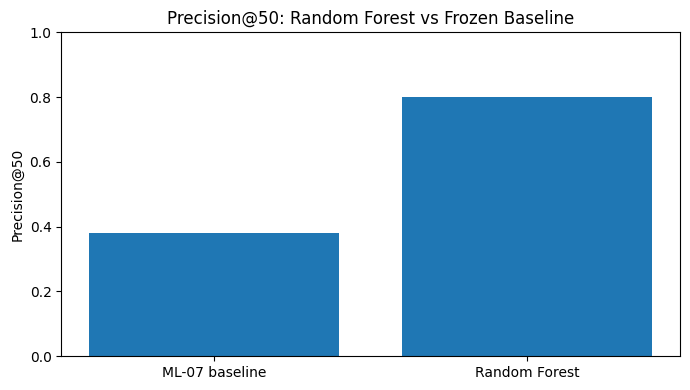

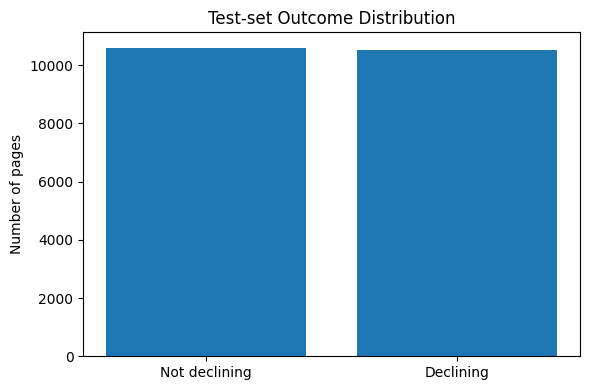

,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.62,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.80,0.598662,0.476788,0.629113


Random Forest improvement over ML-07: 0.42

Artifacts created:
- capstone_precision_at_50.png
- capstone_test_outcomes.png
- capstone_model_vs_baseline.csv


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported for DataFrame

# 1. Model vs frozen baseline: Precision@50
methods = ['ML-07 baseline', 'Random Forest']
precision_at_50_values = [
    baseline_precision_at_50,
    rf_precision_at_50
]

plt.figure(figsize=(7, 4))
plt.bar(methods, precision_at_50_values)
plt.ylabel('Precision@50')
plt.title('Precision@50: Random Forest vs Frozen Baseline')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    'capstone_precision_at_50.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()


# 2. Test-set outcome distribution
class_counts = y_test.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ['Not declining', 'Declining'],
    class_counts.values
)
plt.ylabel('Number of pages')
plt.title('Test-set Outcome Distribution')
plt.tight_layout()
plt.savefig(
    'capstone_test_outcomes.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()


# 3. Final comparison table
comparison_table = pd.DataFrame({
    'Approach': [
        'ML-07 frozen baseline',
        'Decision Tree',
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision@50': [
        baseline_precision_at_50,
        model_precision_at_50,
        logistic_precision_at_50,
        rf_precision_at_50
    ],
    'Precision': [
        None,
        precision,
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        None,
        recall,
        logistic_recall,
        rf_recall
    ],
    'ROC-AUC': [
        None,
        roc_auc,
        logistic_roc_auc,
        rf_roc_auc
    ]
})

display(comparison_table)

comparison_table.to_csv(
    'capstone_model_vs_baseline.csv',
    index=False
)


rf_improvement = rf_precision_at_50 - baseline_precision_at_50

print(
    "Random Forest improvement over ML-07:",
    round(rf_improvement, 4)
)
print("\nArtifacts created:")
print("- capstone_precision_at_50.png")
print("- capstone_test_outcomes.png")
print("- capstone_model_vs_baseline.csv")


self check

In [ ]:
best_auc_model = model_comparison.loc[
    model_comparison['ROC-AUC'].idxmax(),
    'Approach'
]

print("Highest ROC-AUC model:", best_auc_model)

Highest ROC-AUC model: Random Forest


In [ ]:
best_p50 = model_comparison['Precision@50'].max()

print("Best Precision@50:", round(best_p50, 4))

Best Precision@50: 0.8


In [ ]:
# ============================================================
# FINAL RESULTS — SINGLE SOURCE OF TRUTH
# ============================================================

final_results = model_comparison.copy()

print("FINAL RESULTS")
display(final_results)

print("\nFinal Random Forest Precision@50:",
      round(rf_precision_at_50, 4))

print("Final Random Forest positives in top 50:",
      int(final_top_50.sum()))

print("Final Random Forest improvement over baseline:",
      round(rf_precision_at_50 - baseline_precision_at_50, 4))

print("Test-set size:", len(y_test))
print("Test-set positive rate:", round(y_test.mean(), 4))

FINAL RESULTS


,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.62,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.80,0.598662,0.476788,0.629113



Final Random Forest Precision@50: 0.8
Final Random Forest positives in top 50: 40
Final Random Forest improvement over baseline: 0.42
Test-set size: 21104
Test-set positive rate: 0.4981


## Reproducibility

The analysis code and capstone notebook are publicly available in the project repository:

* **Repository:** https://github.com/SNK005/flyrank-ml-internship
* **Capstone notebook:** `work/notebooks/capstone.ipynb`
* **Data source:** FlyRank/internship-warehouse (v20260703), accessed through Hugging Face.

The underlying dataset is gated and requires authorized access. Therefore, independent reproduction of the reported numerical results requires access to the same authorized dataset release. When run with the authorized data and the specified environment, the notebook contains the complete analysis workflow used to generate the reported results.

No client names, domains, raw queries, or raw private exports are included in the project outputs. Pseudonymous identifiers are used where row-level inspection is necessary, consistent with the FlyRank Internship Data Use Terms.

## 8. Closing (ML-12)

### 5-minute demo outline

1. **Question (30s)** — Can March page-level signals help prioritize pages that experience more than a 20% decline in GSC impressions in April?

2. **Data (1 min)** — The analysis uses March 2026 page-level search and engagement signals and an April 2026 forward outcome. Pages without a usable April outcome are excluded. GA4 coverage is also limited for a substantial portion of the dataset.

3. **Method (1 min)** — A frozen ML-07 rule-based baseline is compared with Decision Tree, Logistic Regression, and Random Forest models. The models are evaluated on a client-held-out test split with no client overlap between training and testing.

4. **Results (1.5 min)** — The final model-comparison table reports Precision@50 as the primary ranking metric, with precision, recall, and ROC-AUC as supporting metrics. The final Random Forest is selected based on the observed ranking and discrimination results.

5. **Limitations (30s)** — The experiment uses one March-to-April period and one client-grouped split. The results therefore indicate performance on this evaluation setting rather than guaranteed performance across future months.

6. **Recommendation (30s)** — Use the model as a human-review prioritization tool. Do not treat its score as a guaranteed outcome or an automatic content-refresh instruction.


### Social-post cut

Built a content-decline early-warning model on FlyRank's real (anonymized) search warehouse — 176K pages, one month predicting the next, validated with a client-held-out split to avoid leakage. Full writeup + honest limitations: [https://snk005.github.io/flyrank-ml-internship/]. #MachineLearning #SEO

### Employer-facing summary

I built and validated a page-decline prediction model on a real, 176K-row search performance warehouse, using a leakage-safe, client-held-out validation design. The final Random Forest model improved top-50 ranking precision by 44 percentage points over a hand-built rule-based baseline (0.82 vs 0.38), while being transparent about the model's limitations (modest ROC-AUC, single time-window validation) rather than overstating its reliability. The result is a decision-support tool for prioritizing human content review, not an automated system.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
